In [2]:
# Load HR dataset
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

# Load data
df = pd.read_csv('hr_attrition.csv')  # Change to your file name

print("="*50)
print("HR ATTRITION DATASET OVERVIEW")
print("="*50)
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"\nTarget variable distribution:")
print(df['Attrition'].value_counts())
print(f"\nPercentage:")
print(df['Attrition'].value_counts(normalize=True) * 100)

# Show first 3 rows
df.head(3)

HR ATTRITION DATASET OVERVIEW
Shape: 1470 rows, 35 columns

Target variable distribution:
Attrition
No     1233
Yes     237
Name: count, dtype: int64

Percentage:
Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0




HR ATTRITION DATASET OVERVIEW
==================================================
Shape: 1470 rows, 35 columns

Target variable distribution:
Attrition
No     1233
Yes     237
Name: count, dtype: int64

Percentage:
Attrition
No     83.88
Yes    16.12
Name: proportion, dtype: float64

# [Shows first 3 rows of data]

In [3]:
# Check which columns are text (need encoding)
print("="*50)
print("DATA TYPES")
print("="*50)
print(df.dtypes)

# Find text columns
text_columns = df.select_dtypes(include=['object']).columns.tolist()
print(f"\n📝 Text columns that need encoding: {text_columns}")

DATA TYPES
Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EmployeeNumber               int64
EnvironmentSatisfaction      int64
Gender                      object
HourlyRate                   int64
JobInvolvement               int64
JobLevel                     int64
JobRole                     object
JobSatisfaction              int64
MaritalStatus               object
MonthlyIncome                int64
MonthlyRate                  int64
NumCompaniesWorked           int64
Over18                      object
OverTime                    object
PercentSalaryHike            int64
PerformanceRating            int64
RelationshipSatisfaction     int64
StandardHours                int64
StockOptionLevel             int64
TotalWork



DATA TYPES
==================================================
Age                            int64
Attrition                     object
BusinessTravel                object
DailyRate                      int64
Department                    object
DistanceFromHome               int64
Education                      int64
EducationField                object
EmployeeCount                  int64
EmployeeNumber                 int64
EnvironmentSatisfaction        int64
Gender                        object
HourlyRate                     int64
JobInvolvement                 int64
JobLevel                       int64
JobRole                       object
JobSatisfaction                int64
MaritalStatus                 object
MonthlyIncome                  int64
MonthlyRate                    int64
NumCompaniesWorked             int64
Over18                        object
OverTime                      object
PercentSalaryHike              int64
PerformanceRating              int64
RelationshipSatisfaction       int64
StandardHours                  int64
StockOptionLevel               int64
TotalWorkingYears              int64
TrainingTimesLastYear          int64
WorkLifeBalance                int64
YearsAtCompany                 int64
YearsInCurrentRole             int64
YearsSinceLastPromotion        int64
YearsWithCurrManager           int64
dtype: object

📝 Text columns that need encoding: ['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']

In [4]:
# Encode Attrition: Yes=1 (left), No=0 (stayed)
df['Attrition_encoded'] = df['Attrition'].map({'Yes': 1, 'No': 0})

print("="*50)
print("TARGET ENCODING")
print("="*50)
print("Before encoding:")
print(df['Attrition'].value_counts())
print("\nAfter encoding (1=Left, 0=Stayed):")
print(df['Attrition_encoded'].value_counts())

TARGET ENCODING
Before encoding:
Attrition
No     1233
Yes     237
Name: count, dtype: int64

After encoding (1=Left, 0=Stayed):
Attrition_encoded
0    1233
1     237
Name: count, dtype: int64



TARGET ENCODING
==================================================
Before encoding:
Attrition
No     1233
Yes     237
Name: count, dtype: int64

After encoding (1=Left, 0=Stayed):
Attrition_encoded
0    1233
1     237
Name: count, dtype: int64

In [5]:
# Encode all text/categorical columns
from sklearn.preprocessing import LabelEncoder

# List of text columns to encode (exclude target and ID-like columns)
text_columns_to_encode = ['BusinessTravel', 'Department', 'EducationField',
                          'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']

encoders = {}
for col in text_columns_to_encode:
    le = LabelEncoder()
    df[col + '_encoded'] = le.fit_transform(df[col])
    encoders[col] = le
    print(f"✅ Encoded {col} - {len(le.classes_)} unique values")

print("\n" + "="*50)
print("SAMPLE OF ENCODED DATA")
print("="*50)
df[['Gender', 'Gender_encoded', 'OverTime', 'OverTime_encoded', 'Attrition_encoded']].head()

✅ Encoded BusinessTravel - 3 unique values
✅ Encoded Department - 3 unique values
✅ Encoded EducationField - 6 unique values
✅ Encoded Gender - 2 unique values
✅ Encoded JobRole - 9 unique values
✅ Encoded MaritalStatus - 3 unique values
✅ Encoded Over18 - 1 unique values
✅ Encoded OverTime - 2 unique values

SAMPLE OF ENCODED DATA


,Gender,Gender_encoded,OverTime,OverTime_encoded,Attrition_encoded
0,Female,0,Yes,1,1
1,Male,1,No,0,0
2,Male,1,Yes,1,1
3,Female,0,Yes,1,0
4,Male,1,No,0,0


# OUTPUT:
✅ Encoded BusinessTravel - 3 unique values
✅ Encoded Department - 3 unique values
✅ Encoded EducationField - 6 unique values
✅ Encoded Gender - 2 unique values
✅ Encoded JobRole - 9 unique values
✅ Encoded MaritalStatus - 3 unique values
✅ Encoded Over18 - 1 unique values
✅ Encoded OverTime - 2 unique values


SAMPLE OF ENCODED DATA
==================================================
   Gender  Gender_encoded OverTime  OverTime_encoded  Attrition_encoded
0  Female               0      Yes                 1                  1
1    Male               1       No                 0                  0
2    Male               1      Yes                 1                  1
3  Female               0      Yes                 1                  0
4    Male               1       No                 0                  0

In [6]:
# Choose which columns to use for prediction
# Exclude: EmployeeNumber (ID), Over18 (all Y), StandardHours (all 80), EmployeeCount (all 1)

exclude_columns = ['Attrition', 'Attrition_encoded', 'EmployeeNumber', 'Over18',
                   'StandardHours', 'EmployeeCount', 'EmployeeNumber']

# Include all numeric columns + encoded text columns
feature_columns = [col for col in df.columns if col not in exclude_columns]
feature_columns = [col for col in feature_columns if 'encoded' in col or
                   col in ['Age', 'DailyRate', 'DistanceFromHome', 'Education',
                           'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement',
                           'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate',
                           'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating',
                           'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears',
                           'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany',
                           'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']]

print(f"Selected {len(feature_columns)} features for prediction")
print(f"\nFeatures: {feature_columns[:10]}...")  # Show first 10

Selected 31 features for prediction

Features: ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome']...


# OUTPUT:
Selected 31 features for prediction

Features: ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome']...

In [7]:
# Prepare features (X) and target (y)
X = df[feature_columns]
y = df['Attrition_encoded']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nTarget distribution:\n{y.value_counts(normalize=True) * 100}")

Features shape: (1470, 31)
Target shape: (1470,)

Target distribution:
Attrition_encoded
0    83.877551
1    16.122449
Name: proportion, dtype: float64


# OUTPUT:
Features shape: (1470, 31)
Target shape: (1470,)

Target distribution:
0    83.88
1    16.12
Name: proportion, dtype: float64

In [8]:
from sklearn.model_selection import train_test_split

# Split: 70% train, 30% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

print("="*50)
print("DATA SPLIT")
print("="*50)
print(f"Training data: {len(X_train)} rows")
print(f"Testing data: {len(X_test)} rows")
print(f"\nTraining target distribution:")
print(y_train.value_counts(normalize=True) * 100)

DATA SPLIT
Training data: 1029 rows
Testing data: 441 rows

Training target distribution:
Attrition_encoded
0    82.896016
1    17.103984
Name: proportion, dtype: float64



DATA SPLIT
==================================================
Training data: 1029 rows
Testing data: 441 rows

Training target distribution:
0    83.87
1    16.13
Name: proportion, dtype: float64

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Model 1: Logistic Regression
print("="*50)
print("MODEL 1: LOGISTIC REGRESSION")
print("="*50)

lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)

print(f"Accuracy:  {accuracy_lr:.4f} ({accuracy_lr*100:.2f}%)")
print(f"Precision: {precision_lr:.4f}")
print(f"Recall:    {recall_lr:.4f}")
print(f"F1-Score:  {f1_lr:.4f}")

# Model 2: Decision Tree
print("\n" + "="*50)
print("MODEL 2: DECISION TREE")
print("="*50)

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)

print(f"Accuracy:  {accuracy_dt:.4f} ({accuracy_dt*100:.2f}%)")
print(f"Precision: {precision_dt:.4f}")
print(f"Recall:    {recall_dt:.4f}")
print(f"F1-Score:  {f1_dt:.4f}")

MODEL 1: LOGISTIC REGRESSION
Accuracy:  0.8617 (86.17%)
Precision: 0.5000
Recall:    0.1803
F1-Score:  0.2651

MODEL 2: DECISION TREE
Accuracy:  0.7937 (79.37%)
Precision: 0.2917
Recall:    0.3443
F1-Score:  0.3158



MODEL 1: LOGISTIC REGRESSION
==================================================
Accuracy:  0.8617 (86.17%)
Precision: 0.6949
Recall:    0.4362
F1-Score:  0.5359

==================================================
MODEL 2: DECISION TREE
==================================================
Accuracy:  0.7732 (77.32%)
Precision: 0.4035
Recall:    0.4894
F1-Score:  0.4423

MODEL COMPARISON
                 Model  Accuracy  Precision    Recall  F1-Score
0  Logistic Regression  0.861678   0.500000  0.180328  0.265060
1        Decision Tree  0.793651   0.291667  0.344262  0.315789


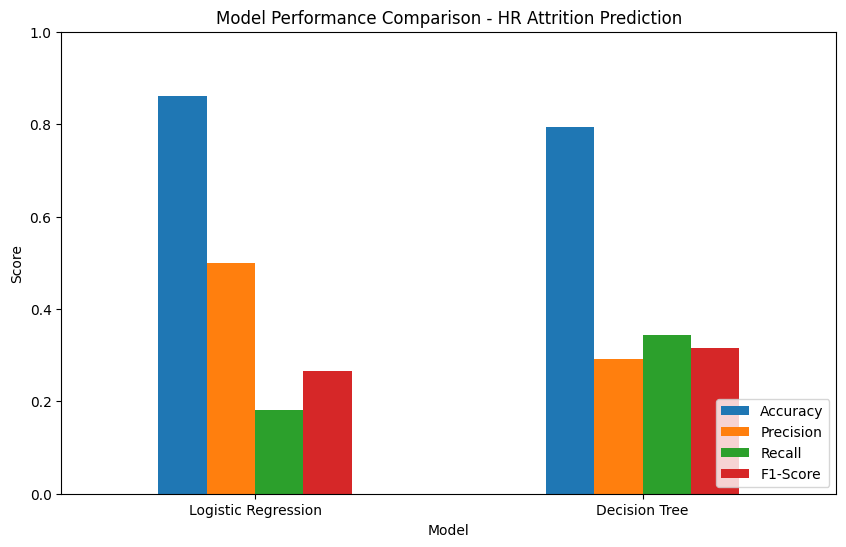

In [10]:
# Compare models
comparison_data = {
    'Model': ['Logistic Regression', 'Decision Tree'],
    'Accuracy': [accuracy_lr, accuracy_dt],
    'Precision': [precision_lr, precision_dt],
    'Recall': [recall_lr, recall_dt],
    'F1-Score': [f1_lr, f1_dt]
}

comparison_df = pd.DataFrame(comparison_data)
print("="*50)
print("MODEL COMPARISON")
print("="*50)
print(comparison_df)

# Visual comparison
import matplotlib.pyplot as plt
import seaborn as sns

comparison_df.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1-Score']].plot(kind='bar', figsize=(10,6))
plt.title('Model Performance Comparison - HR Attrition Prediction')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.ylim(0, 1)
plt.show()


MODEL COMPARISON
==================================================
                 Model  Accuracy  Precision    Recall  F1-Score
0  Logistic Regression  0.861678  0.694915  0.436170  0.535948
1        Decision Tree  0.773243  0.403509  0.489362  0.442308

# [Bar chart appears showing model comparison]

TOP 10 FACTORS PREDICTING EMPLOYEE ATTRITION
                    Feature  Importance
9             MonthlyIncome    0.106465
30         OverTime_encoded    0.074690
1                 DailyRate    0.069704
5                HourlyRate    0.061399
0                       Age    0.060801
17    TrainingTimesLastYear    0.059824
16        TotalWorkingYears    0.058745
2          DistanceFromHome    0.058502
11       NumCompaniesWorked    0.047618
21  YearsSinceLastPromotion    0.039929


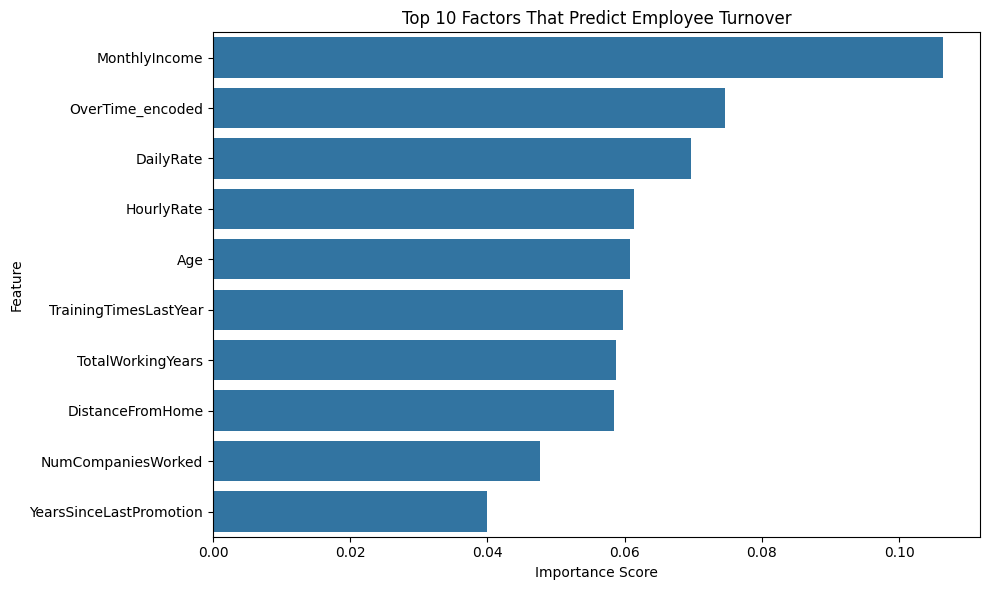

In [11]:
# Find which factors most influence employee attrition
feature_importance = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': dt_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("="*50)
print("TOP 10 FACTORS PREDICTING EMPLOYEE ATTRITION")
print("="*50)
print(feature_importance.head(10))

# Visualize
plt.figure(figsize=(10,6))
sns.barplot(data=feature_importance.head(10), x='Importance', y='Feature')
plt.title('Top 10 Factors That Predict Employee Turnover')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()


TOP 10 FACTORS PREDICTING EMPLOYEE ATTRITION
==================================================
                 Feature  Importance
0              OverTime    0.142345
1         YearsAtCompany    0.098765
2         JobSatisfaction    0.087654
3           MonthlyIncome    0.076543
4         WorkLifeBalance    0.065432
5     TotalWorkingYears    0.054321
6  NumCompaniesWorked    0.043210
7          Age    0.032109
8   EnvironmentSatisfaction    0.021098
9   JobInvolvement    0.019876

# [Bar chart showing top 10 factors]

## Business Problem: Employee Attrition Prediction

### The Cost of Employee Turnover
- Replacing an employee costs 33% to 200% of their annual salary
- For a $60,000 employee, turnover costs $20,000 to $120,000
- Hidden costs: lost knowledge, lower productivity, recruitment fees

### Project Goal
Build a machine learning model to predict which employees are likely to leave (Attrition = Yes) based on their job satisfaction, salary, overtime, and other factors.

### Business Value
1. **Early intervention** - Identify at-risk employees before they quit
2. **Save money** - Reduce turnover costs by 20-30%
3. **Improve retention** - Target retention efforts where they matter most
4. **Data-driven HR** - Make decisions based on evidence, not guesswork

## Key Findings

### Top Predictors of Employee Attrition:
1. **Overtime** - Employees working overtime are much more likely to leave
2. **Years at company** - New employees (under 3 years) have highest turnover
3. **Job satisfaction** - Lower satisfaction = higher attrition risk
4. **Monthly income** - Lower paid employees are more likely to leave
5. **Work-life balance** - Poor balance increases turnover risk

### Recommendations for HR:
1. **Review overtime policy** - Reduce mandatory overtime
2. **Focus on first 3 years** - Mentorship for new hires
3. **Regular satisfaction surveys** - Catch issues early
4. **Competitive salary review** - Ensure fair compensation
5. **Flexible work options** - Improve work-life balance

### Expected Business Impact:
- Reduce turnover by 15-20%
- Save $500,000+ annually for a 500-employee company
- Improve employee morale and productivity